# DentalYOLO26

This notebook contains the training, evaluation, and analysis pipeline
for DentalYOLO26.

The notebook preserves the experimental workflow used in the research
study and is intended to support reproducibility.

> **Reproducibility note:** The code structure and experimental settings
> are kept consistent with the research implementation. Users should
> modify only the configuration parameters explicitly marked below.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Stage 0 — Environment Setup

This stage prepares the Python environment and imports the libraries
required for the DentalYOLO26 research pipeline.

### Tasks

- Install or verify required dependencies
- Import required libraries
- Check the execution environment

In [ ]:
!rm -rf /content/sample_data

In [ ]:
from pathlib import Path
from urllib.parse import urlparse
import shutil, subprocess
from google.colab import output
import sys
from pathlib import Path
import logging
import sys
import time
import yaml

In [ ]:
# Install the required packages for the experiment.
def git_update(repo_url="https://github.com/tommyngx/DentalYOLO.git"):
    %cd /content
    repo_name = Path(urlparse(repo_url).path).stem
    target = Path.cwd() / repo_name
    if target.exists():
        shutil.rmtree(target)  # remove
    subprocess.run(["git", "clone", repo_url, str(target)], check=True)
    return target
git_update("https://github.com/tommyngx/DentalYOLO.git")

/content


PosixPath('/content/DentalYOLO')

In [ ]:
%cd /content/DentalYOLO
%pip install -qr requirements.txt  # install

/content/DentalYOLO
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 130.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.0 MB/s eta 0:00:00


In [ ]:
# Verify the library versions used by the experiment.
# Keep these versions consistent when reproducing the reported results.
CUSTOM_ROOT = Path("/content/DentalYOLO/ultralytics")
for m in list(sys.modules):
    if m.startswith("ultralytics"):
        del sys.modules[m]
sys.path.insert(0, str(CUSTOM_ROOT))
import ultralytics
from ultralytics import YOLO
print("Using ultralytics from:", ultralytics.__file__)
logger = logging.getLogger("ultralytics")
if len(logger.handlers) > 1:
    logger.handlers = logger.handlers[:1]
logger.propagate = False
print("Number of ultralytics handlers after fix:", len(logger.handlers))
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using ultralytics from: /content/DentalYOLO/ultralytics/__init__.py
Number of ultralytics handlers after fix: 1
8.4.75


In [ ]:
from pathlib import Path
from ultralytics import YOLO
import time
T_START = time.time()


## Stage 1 — Configuration

This stage defines the dataset, model, training, evaluation, and
output configuration used throughout the notebook.

### Task — Experiment Configuration

Update the dataset, model, or experiment parameters here when running
a different experiment.

> **Important:** Parameters used to reproduce the reported research
> results should not be changed unless a new experiment is intended.

In [ ]:
import os
from dataclasses import dataclass


In [ ]:
@dataclass
class Config:
    # PROJECT
    project_dir: str = "/content/drive/MyDrive/Your-Project"
    experiment_name: str = "experiment_name"

    # DATA
    # Change this to the dataset you want to use.
    dataset_name: str = "dataset_name"
    # Change this to your dataset ZIP file.
    zip_dataset: str = os.path.join(
        project_dir,
        "datasets",
        f"{dataset_name}.zip"
    )

    # MODEL
    # Change this to select the model used in the experiment.
    model_name: str = "dental-yolo26n_v15"

    # TRAINING
    epochs: int = 100 # Number of training epochs.
    imgsz: int = 640 # Training batch size.
    batchsize: int = 8 # Input image size used during training and evaluation.
    seed: int = 2026 # Random seed used for reproducibility.

cfg = Config()

# PATH SETUP
cfg.output_root = os.path.join(cfg.project_dir, "output")

cfg.output_dir = os.path.join(
    cfg.output_root,
    cfg.dataset_name,
    cfg.model_name,
)
cfg.result_dir = os.path.join(
    cfg.output_dir,
    cfg.experiment_name,
)
# This file defines the dataset paths, number of classes, and class names.
cfg.data_dir = os.path.join("/content", cfg.dataset_name)
cfg.yaml_path = os.path.join(cfg.data_dir, "data.yaml")
# create dirs
os.makedirs(cfg.output_dir, exist_ok=True)

print("Output dir:", cfg.output_dir)
print("Data dir:", cfg.data_dir)


Output dir: /content/drive/MyDrive/Oral_Disease_Detection/output/dental_opg_2024/dental-yolo26s_v15
Data dir: /content/dental_opg_2024


## Stage 2 — Dataset Preparation

This stage prepares and verifies the dataset before model training.

### Tasks

- Locate the dataset
- Read the dataset configuration
- Verify image and label directories
- Check dataset structure
- Prepare the dataset for training and evaluation

In [ ]:
# Extract the dataset ZIP archive if it has not already been prepared.
!unzip -q {cfg.zip_dataset} -d /content/
print("Dataset ready:", cfg.data_dir)

Dataset ready: /content/dental_opg_2024


In [ ]:
# Verify that the expected image and label directories are available.
assert os.path.exists(cfg.yaml_path), "Missing data.yaml"
assert os.path.exists(os.path.join(cfg.data_dir, "train")), "Missing train folder"
assert os.path.exists(os.path.join(cfg.data_dir, "val")), "Missing val folder"

print("Dataset structure OK ✅")

Dataset structure OK ✅


In [ ]:
from ultralytics import YOLO
from ultralytics import settings

settings.update({"datasets_dir": ""})

In [ ]:
import yaml

def fix_data_yaml(yaml_path, dataset_name):
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)

    # Update path
    new_path = f"/content/{dataset_name}"
    data["path"] = new_path

    with open(yaml_path, "w") as f:
        yaml.safe_dump(data, f, sort_keys=False)

    print(f"Updated path -> {new_path}")
    return data

fix_data_yaml(cfg.yaml_path, cfg.dataset_name)

Updated path -> /content/dental_opg_2024


{'path': '/content/dental_opg_2024',
 'train': 'train/images',
 'val': 'val/images',
 'test': 'test/images',
 'nc': 6,
 'names': {0: 'Healthy teeth',
  1: 'Infection',
  2: 'Impacted teeth',
  3: 'Broken-down crown or root (BDC/BDR)',
  4: 'Fractured teeth',
  5: 'Caries'}}

## Stage 3 — Model Training

This stage builds and trains the selected DentalYOLO26 model using
the dataset and training configuration defined above.

### Tasks

- Build the selected model
- Load pretrained weights when applicable
- Configure training parameters
- Run model training
- Save training outputs

In [ ]:
# Build the selected model using the configured model name.
dental_model = YOLO(f'{cfg.model_name}.yaml')
dental_model.load("yolo26s.pt")

# Start model training.
# The training parameters are kept consistent with the research experiment.
dental_results = dental_model.train(
    data=cfg.yaml_path,
    epochs=cfg.epochs,
    imgsz=cfg.imgsz,
    batch=cfg.batchsize,
    seed=cfg.seed,
    project=cfg.output_dir,
    name=cfg.experiment_name,

    # Device
    device=0,
    exist_ok=True,
)
print(f"\nDentalYOLO26 trained.  Total elapsed: {(time.time()-T_START)/60:.1f} min")



Transferred 171/751 items from pretrained weights
New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dental_opg_2024/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=dental-yolo

In [ ]:
# SAVE CONFIG

import platform
import time
import torch
from datetime import datetime

from pathlib import Path
config_path = Path(dental_results.save_dir) / "config.yaml"
with open(config_path, "w") as f:
    yaml.safe_dump(vars(cfg), f, sort_keys=False)
print(f"Saved config: {config_path}")

# SAVE MODEL SUMMARY
summary_path = Path(dental_results.save_dir) / "model_summary.txt"
layers, params, grads, gflops = dental_model.info(detailed=True)
with open(summary_path, "w") as f:
    f.write(f"{layers} layers\n")
    f.write(f"{params:,} parameters\n")
    f.write(f"{grads:,} gradients\n")
    f.write(f"{gflops:.2f} GFLOPs\n")
print(f"Saved model summary: {summary_path}")

# SAVE ENVIRONMENT
env_path = Path(dental_results.save_dir) / "environment.txt"
with open(env_path, "w") as f:
    f.write(f"Date          : {datetime.now()}\n")
    f.write(f"Platform      : {platform.platform()}\n")
    f.write(f"Python        : {platform.python_version()}\n")
    f.write(f"Torch         : {torch.__version__}\n")
    f.write(f"CUDA          : {torch.version.cuda}\n")
    f.write(f"Ultralytics   : {ultralytics.__version__}\n")
    if torch.cuda.is_available():
        f.write(f"GPU           : {torch.cuda.get_device_name(0)}\n")
print(f"Saved environment: {env_path}")

Saved config: /content/drive/MyDrive/02_UTS_2026/Neural Network and Fuzzy Logic/Oral_Disease_Detection/output/dental_opg_2024/dental-yolo26s_v15/exp4_e100_b8/config.yaml
layer                                    name                type  gradient  parameters               shape        mu     sigma
    0                     model.0.conv.weight              Conv2d     False         864       [32, 3, 3, 3]  -0.00161     0.317        float32
    1                       model.0.bn.weight         BatchNorm2d     False          32                [32]     0.999    0.0504        float32
    1                         model.0.bn.bias         BatchNorm2d     False          32                [32]   -0.0102    0.0453        float32
    2                             model.0.act                SiLU     False           0                  []         -         -              -
    3                     model.1.conv.weight              Conv2d     False       18432      [64, 32, 3, 3]    -0.002    0.0355   

## History train

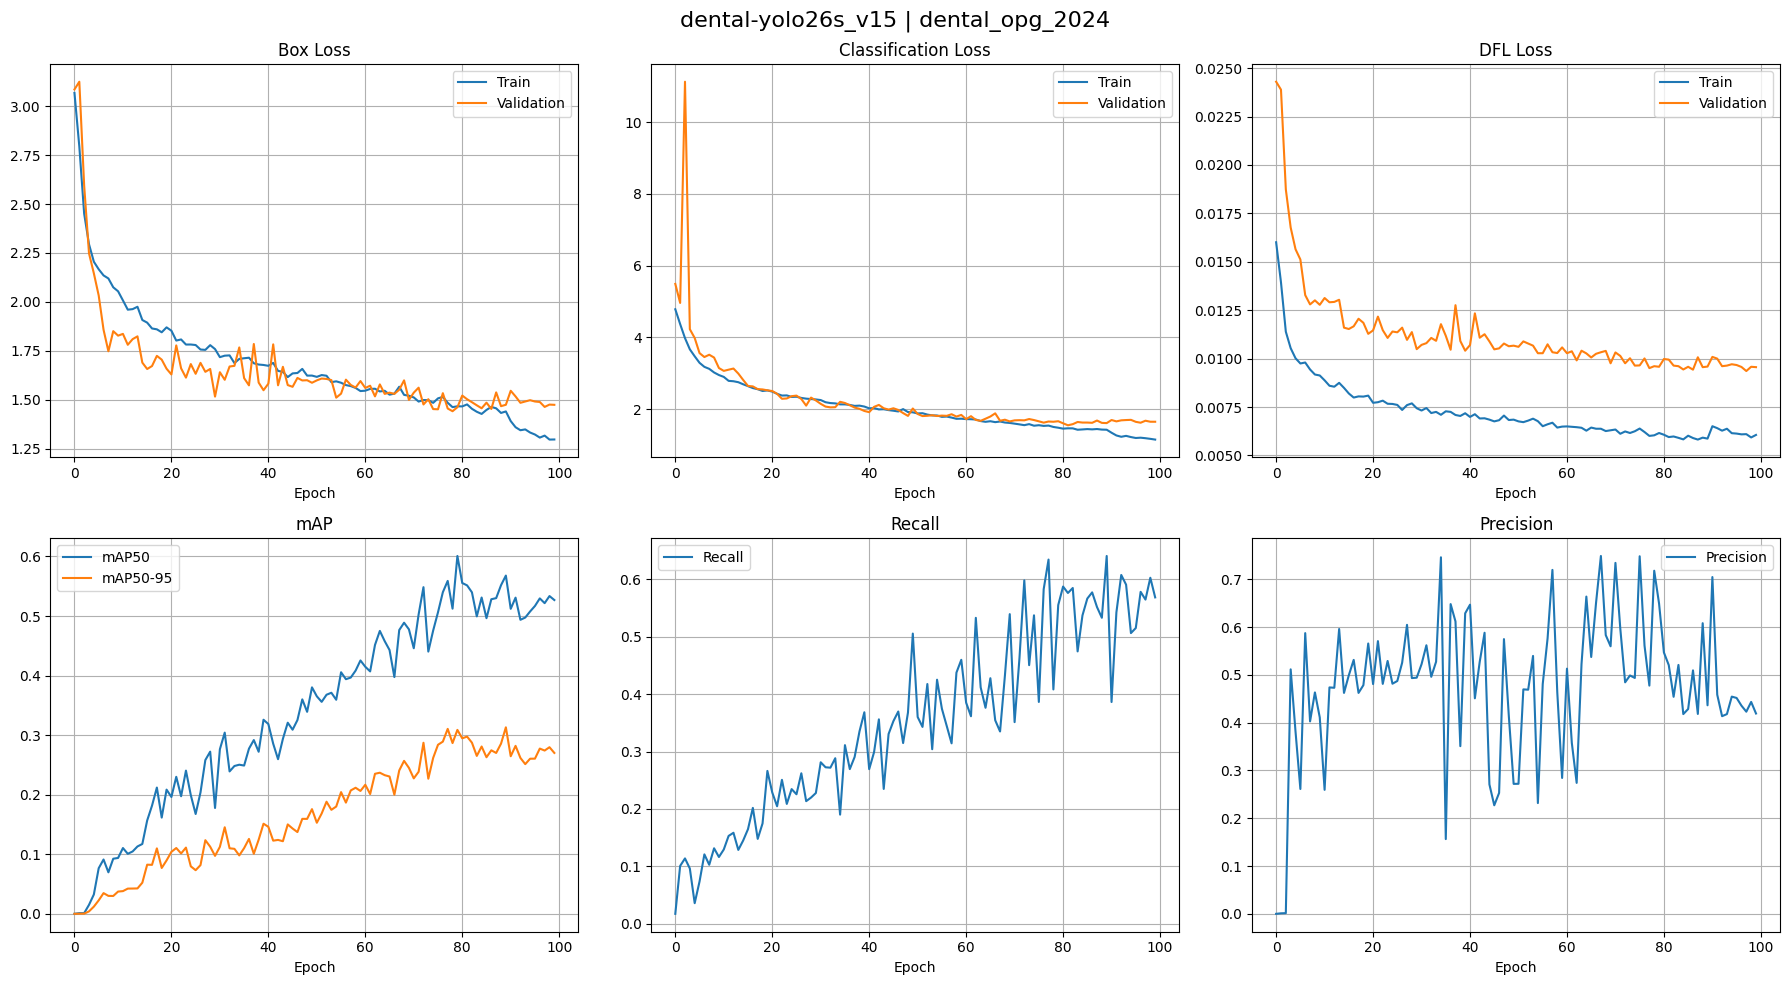

In [ ]:
import os
import math
import matplotlib.pyplot as plt
import pandas as pd

# LOAD TRAINING HISTORY
history_path = os.path.join(cfg.result_dir, "results.csv")
df = pd.read_csv(history_path)


# LOSS MAPPING
LOSS_MAPPING = {
    "box_loss":  "Box Loss",
    "giou_loss": "GIoU Loss",
    "cls_loss":  "Classification Loss",
    "dfl_loss":  "DFL Loss",
    "l1_loss":   "L1 Loss",
}

losses = []
for loss in LOSS_MAPPING:
    train_col = f"train/{loss}"
    if train_col in df.columns:
        losses.append(loss)

# FIGURE
n_loss = len(losses)
n_cols = max(3, n_loss)
fig, axs = plt.subplots(2,n_cols,figsize=(6 * n_cols, 10),)

# If only one column, convert to 2D array
if n_cols == 1:
    axs = axs.reshape(2, 1)

# LOSS CURVES
for i, loss in enumerate(losses):
    train_col = f"train/{loss}"
    val_col = f"val/{loss}"
    ax = axs[0, i]
    if train_col in df.columns:
        ax.plot(df[train_col], label="Train")
    if val_col in df.columns:
        ax.plot(df[val_col], label="Validation")
    ax.set_title(LOSS_MAPPING[loss])
    ax.set_xlabel("Epoch")
    ax.grid(True)
    ax.legend()

# Hide unused loss subplots
for i in range(len(losses), n_cols):
    axs[0, i].axis("off")

# METRICS
metric_plots = [
    (
        "mAP",
        [
            ("metrics/mAP50(B)", "mAP50"),
            ("metrics/mAP50-95(B)", "mAP50-95"),
        ],
    ),

    (
        "Recall",
        [
            ("metrics/recall(B)", "Recall"),
        ],
    ),

    (
        "Precision",
        [
            ("metrics/precision(B)", "Precision"),
        ],
    ),
]

for i, (title, curves) in enumerate(metric_plots):
    ax = axs[1, i]
    for column, label in curves:
        if column in df.columns:
            ax.plot(df[column], label=label)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True)
    ax.legend()

# Hide unused metric subplots
for i in range(len(metric_plots), n_cols):
    axs[1, i].axis("off")

plt.suptitle(f"{cfg.model_name} | {cfg.dataset_name}",fontsize=16,)
plt.tight_layout()
plt.show()

## Stage 4 — Model Validation

This stage evaluates the trained model using the validation/test
configuration defined in the experiment.

### Tasks

- Run model validation
- Collect detection metrics
- Inspect validation results

In [ ]:
# Evaluate the trained model on the configured dataset split.
!python scripts/validate.py \
    --data {cfg.yaml_path} \
    --project {cfg.output_dir} \
    --name {cfg.experiment_name} \
    --batch {cfg.batchsize} \
    --imgsz {cfg.imgsz} \
    --device 0

Model      : /content/drive/MyDrive/Oral_Disease_Detection/output/dental_opg_2024/dental-yolo26s_v15/exp4_e100_b8/weights/best.pt
Dataset    : /content/dental_opg_2024/data.yaml
Experiment : exp4_e100_b8

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
dental-YOLO26s_v15 summary (fused): 148 layers, 10,008,948 parameters, 0 gradients, 21.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 39.6±17.6 MB/s, size: 45.2 KB)
val: Scanning /content/dental_opg_2024/test/labels... 23 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 23/23 1.1Kit/s 0.0s
val: New cache created: /content/dental_opg_2024/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.1it/s 1.0s
                   all         23        102      0.738      0.536      0.657      0.379
         Healthy teeth         14         26      0.463      0.231      0.347      0.205
             Infection          2   

## Stage 5 — COCO Evaluation

This stage performs COCO-style evaluation to obtain the detection
metrics used for research comparison.

### Tasks

- Prepare ground-truth annotations
- Convert predictions to COCO format
- Run COCO evaluation
- Collect AP metrics

In [ ]:
!python scripts/coco_evaluate.py \
    --data {cfg.yaml_path} \
    --project {cfg.output_dir} \
    --name {cfg.experiment_name}

Generating test_coco_gt.json...
Saved COCO GT: /content/drive/MyDrive/Oral_Disease_Detection/output/dental_opg_2024/dental-yolo26s_v15/exp4_e100_b8/validation/test_coco_gt.json
Images      : 23
Annotations : 102
Categories  : 6
Sample image_id: '104_jpg.rf.05501644f89b63b3f9ba38f2c2436c75' (type: str)
[exp4_e100_b8] Predictions: 535
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.04s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.371
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.644
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.374
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=